# 2.3 Bluesky — Textual Analysis

This notebook performs textual analysis on the Bluesky silver-layer data, characterising vocabulary, term importance, and latent topic structure across candidate buzz clusters (TrumpBuzz · HarrisBuzz · ElectionBuzz).

**Pipeline:**  
Silver → TF-IDF → spell correction → SVD/LSA → key term tracking → word clouds

**Input:** `Data/2_Silver/Bluesky/bluesky_clean.csv`


<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Text Length Distribution](#1-text-length-distribution)
- [2. Preprocessing Quality Check](#2-preprocessing-quality-check)
- [3. TF-IDF Analysis](#3-tf-idf-analysis)
- [4. SVD / Latent Semantic Analysis](#4-svd--latent-semantic-analysis)
- [5. Key Term Frequency Over Time](#5-key-term-frequency-over-time)
- [6. Word Clouds](#6-word-clouds)


## Setup

In [1]:
import sys
sys.path.insert(0, '../..')
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from symspellpy import SymSpell, Verbosity
import pkg_resources
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from wordcloud import WordCloud

from house_style import *
from Functions.data_splits import get_cv_folds, get_test_split

apply_style()


In [ ]:
# Locate project root by searching upward for the Data folder
root = Path.cwd()
while root != root.parent:
    if (root / "Data").exists():
        break
    root = root.parent
os.chdir(root)
print("Working directory:", root)

In [4]:
bluesky_df = pd.read_csv("Data/2_Silver/Bluesky/bluesky_clean.csv")


In [5]:
bluesky_df.head()

,uri,author,display,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,query,parent_uri,detected_lang,text_clean,words,word_count,candidate
0,at://did:plc:lpqouffbl3gbah3r23vh7odp/app.bsky...,runhudi.bsky.social,Yehuda M.,Canadian election prediction: Americans will g...,2024-11-04 23:44:15.319000+00:00,0,0,1,[],False,post,#USElection2024,NaN,en,canadian election prediction americans polls d...,"['canadian', 'election', 'prediction', 'americ...",24,TrumpBuzz
1,at://did:plc:3ixumkojw3dpsfhdyjodfxmk/app.bsky...,manabouttown.bsky.social,NaN,Why are swinger states so important in the #US...,2024-11-04 23:35:21.961000+00:00,0,0,0,[],False,post,#USElection2024,NaN,en,swinger states important uselection really man...,"['swinger', 'states', 'important', 'uselection...",8,ElectionBuzz
2,at://did:plc:pebmhdoqw45rp5bpu53myfoc/app.bsky...,justdev1.bsky.social,That Dev Guy,If Joe Biden winning felt like Return of the J...,2024-11-04 23:23:51.647000+00:00,0,0,0,[],False,post,#USElection2024,NaN,en,joe biden winning felt like return jedi end el...,"['joe', 'biden', 'winning', 'felt', 'like', 'r...",16,HarrisBuzz
3,at://did:plc:bj6epztbrubmkloj4ethecvy/app.bsky...,alexverbeek.bsky.social,Alexander Verbeek,Will the U.S. Presidential Elections be a Turn...,2024-11-04 22:48:56.805000+00:00,3,1,1,[],False,post,#USElection2024,NaN,en,presidential elections turning point history t...,"['presidential', 'elections', 'turning', 'poin...",9,ElectionBuzz
4,at://did:plc:fgdeud5a7fzfwdx7pg5m63xy/app.bsky...,tuomoliljenback.bsky.social,Tuomo Liljenbäck,Dear American voters! As a foreigner living in...,2024-11-04 22:10:36.540000+00:00,0,0,1,[],False,post,#USElection2024,NaN,en,dear american voters foreigner living finland ...,"['dear', 'american', 'voters', 'foreigner', 'l...",24,HarrisBuzz


In [6]:
bluesky_df.columns

Index(['uri', 'author', 'display', 'text', 'timestamp', 'likes', 'reposts',
       'replies', 'mentions', 'is_reply', 'post_type', 'query', 'parent_uri',
       'detected_lang', 'text_clean', 'words', 'word_count', 'candidate'],
      dtype='object')

In [19]:
# Keep core columns
df = bluesky_df[['text', 'timestamp', 'likes', 'reposts', 'replies', 'mentions', 'is_reply', 'post_type', 'text_clean', 'words', 'word_count', 'candidate']].copy()

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)

df = df.dropna(subset=['timestamp']).copy()

# Date/time features

ts = df['timestamp']
df['date'] = ts.dt.date
df['hour'] = ts.dt.hour
df['weekday'] = ts.dt.day_name()

print('rows', len(df), 'from', df['timestamp'].min(), 'to', df['timestamp'].max())
print('Distinct dates', df['date'].nunique())

rows 23592 from 2024-07-05 03:04:25.279000+00:00 to 2026-01-19 01:45:26.080000+00:00
Distinct dates 176


In [20]:
df.dtypes

text                       object
timestamp     datetime64[ns, UTC]
likes                       int64
reposts                     int64
replies                     int64
mentions                   object
is_reply                     bool
post_type                  object
text_clean                 object
words                      object
word_count                  int64
candidate                  object
date                       object
hour                        int32
weekday                    object
dtype: object

In [21]:
df['date'] = pd.to_datetime(df['date'])

In [23]:
df['text'].str.contains('#USElection2024').value_counts()

text
False    23289
True       303
Name: count, dtype: int64

In [24]:
df['text'] = df['text'].str.replace('#USElection2024', '', regex=True)
df['text'].str.contains('#USElection2024').value_counts()

text
False    23592
Name: count, dtype: int64

In [25]:
df['text'].duplicated().value_counts()

text
False    23023
True       569
Name: count, dtype: int64

In [31]:
top_text = df['text'].value_counts().index[0]
df[df['text'] == top_text].head(3)

,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,text_clean,words,word_count,candidate,date,hour,weekday
16731,💙V🌊O🗳T💙E🌊 🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸 #vote #election2024 #...,2024-11-02 17:25:23.600000+00:00,0,0,0,[],False,post,vote election harriswalz saveamerica fightfasc...,"['vote', 'election', 'harriswalz', 'saveameric...",17,HarrisBuzz,2024-11-02,17,Saturday
16733,💙V🌊O🗳T💙E🌊 🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸 #vote #election2024 #...,2024-11-02 13:37:52.174000+00:00,0,0,0,[],False,post,vote election harriswalz saveamerica fightfasc...,"['vote', 'election', 'harriswalz', 'saveameric...",17,HarrisBuzz,2024-11-02,13,Saturday
16734,💙V🌊O🗳T💙E🌊 🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸 #vote #election2024 #...,2024-11-02 10:30:04.553000+00:00,3,0,0,[],False,post,vote election harriswalz saveamerica fightfasc...,"['vote', 'election', 'harriswalz', 'saveameric...",17,HarrisBuzz,2024-11-02,10,Saturday


In [34]:
df_new = df.sort_values('timestamp').drop_duplicates(subset='text', keep='last')

In [35]:
len(df_new)

23023

In [36]:
df_new.duplicated().sum()

np.int64(0)

In [37]:
df_new.duplicated(subset=['text']).sum()

np.int64(0)

## 1. Text Length Distribution

### Analyzing Post Length Distribution

Understanding how long Bluesky posts are (in characters) gives a first sense of the data. Bluesky enforces a 300-character limit per post, so unlike Reddit comments the distribution has a hard ceiling. Still, many posts will be short reactions or links, while others push the limit with more substantive content. The histogram reveals where the bulk of posts cluster and whether users typically write short or near-maximum-length content.

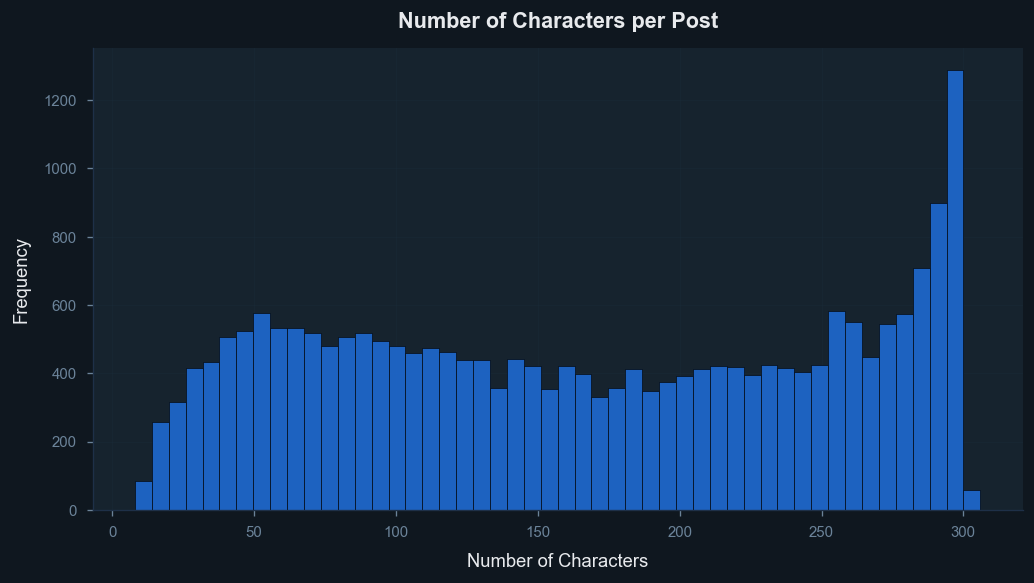

Average characters per post: 166.1
Median characters per post: 163.0


In [38]:
# Calculate character count for each review
char_counts = df_new['text'].str.len()

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(char_counts, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.title('Number of Characters per Post')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average characters per post: {char_counts.mean():.1f}")
print(f"Median characters per post: {char_counts.median():.1f}")

### Word Count Distribution

Word count provides a linguistically more meaningful measure of post length than character count, since it captures how much a user actually wrote independent of word length. On a short-form platform like Bluesky, the distribution is expected to be concentrated in the lower range — most posts say something in a handful of words — with a long tail of more detailed posts. This complements the character-length view and helps set expectations for downstream text models.

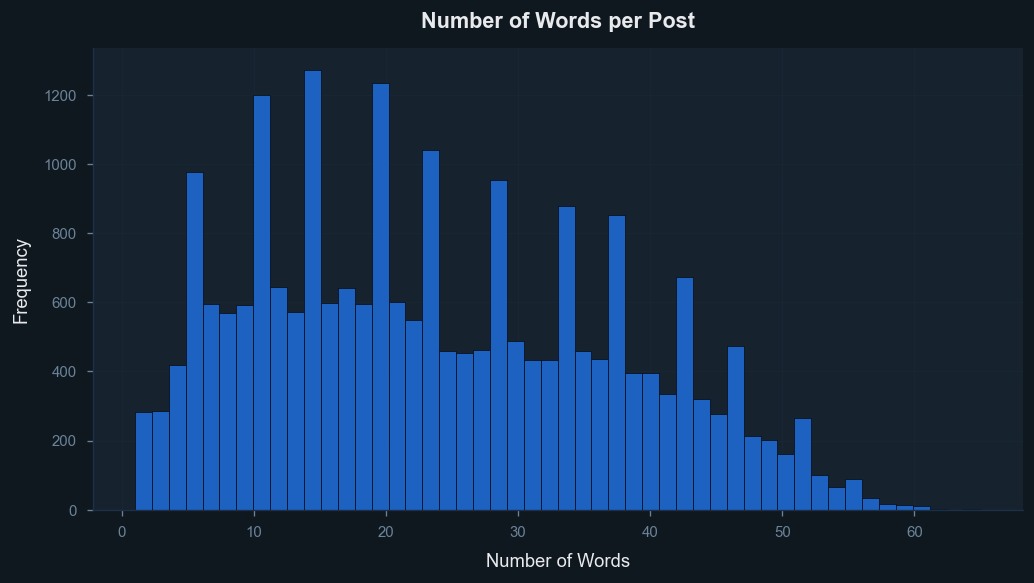

Average words per post: 24.0
Median words per post: 22.0


In [39]:
# Calculate word count for each review
word_counts = df_new['text'].str.split().str.len()

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(word_counts, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Number of Words per Post')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average words per post: {word_counts.mean():.1f}")
print(f"Median words per post: {word_counts.median():.1f}")

## 2. Preprocessing Quality Check

#### Preprocessing

The text has already been cleaned in an earlier pipeline step (lowercasing, stopword removal, punctuation stripping). Here we verify vocabulary coverage before and after preprocessing to quantify how much noise was removed. A large vocabulary reduction indicates the raw text contained many rare or malformed tokens — hashtag fragments, URLs, emoji sequences — that add no signal for topic modelling.

In [42]:
df_new['text_clean'] = df_new['text_clean'].fillna('')

In [43]:
import re

def unique_word_count(texts):
    """Count unique words across all documents."""
    if isinstance(texts, pd.Series):
        texts = texts.tolist()
    elif isinstance(texts, str):
        texts = [texts]
    
    unique_words = set()
    for text in texts:
        words = text.split()
        unique_words.update(words)
    
    return len(unique_words)

# Baseline: count unique words in original reviews before any preprocessing
baseline_count = unique_word_count(df_new['text'])
print(f"✓ Baseline unique words: {baseline_count:,}")
print(f"\nThis represents the vocabulary size before preprocessing.")

✓ Baseline unique words: 77,971

This represents the vocabulary size before preprocessing.


In [44]:
final_count = unique_word_count(df_new['text_clean'])

print(f"  Total reduction: {baseline_count - final_count:,} words")
print(f"  Final vocabulary: {final_count:,} unique words")
print(f"  Original vocabulary: {baseline_count:,} unique words")

  Total reduction: 49,946 words
  Final vocabulary: 28,025 unique words
  Original vocabulary: 77,971 unique words


### Before vs. After Comparison

To verify the preprocessing pipeline behaves correctly, we compare the raw and cleaned text for a sample post. The cleaning steps — lowercasing, stopword removal, punctuation stripping, and URL removal — should yield a compact, noise-free representation. This sanity check also helps catch unintended side effects, such as meaningful political terms being accidentally dropped.

In [45]:
# Compare example review before and after preprocessing
idx = 20

print("="*80)
print("BEFORE PREPROCESSING:")
print("="*80)
print(df_new['text'].iloc[idx][:200])

print("="*80)
print("AFTER PREPROCESSING:")
print("="*80)
print(df_new['text_clean'].iloc[idx][:200])

BEFORE PREPROCESSING:
After the NYT ignored her for four years? And the WP. Anything to push out Joe Biden and excuse tRump.
AFTER PREPROCESSING:
nyt ignored four years anything push joe biden excuse trump


In [46]:
start_date = '2024-07-05'
end_date = '2024-11-04'

mask = (df_new['date'] >= start_date) & (df_new['date'] <= end_date)
df_new = df_new.loc[mask]

# 4. Optional: Reset the index so it starts from 0 again
df_new = df_new.reset_index(drop=True)

# 5. Check the result
print(f"Number of rows after filtering: {len(df_new)}")
print(f"Date range: {df_new['date'].min()} to {df_new['date'].max()}")

Number of rows after filtering: 22859
Date range: 2024-07-05 00:00:00 to 2024-11-04 00:00:00


In [47]:
df_new.head(1)

,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,text_clean,words,word_count,candidate,date,hour,weekday
0,"In 1970, the Club of Rome predicted a crash ea...",2024-07-05 03:04:25.279000+00:00,4,2,1,[],False,post,club rome predicted crash early century far pr...,"['club', 'rome', 'predicted', 'crash', 'early'...",27,TrumpBuzz,2024-07-05,3,Friday


## 3. TF-IDF Analysis

### Creating the Document-Term Matrix with TF-IDF

TF-IDF (Term Frequency–Inverse Document Frequency) transforms each post into a numeric vector that reflects how distinctive each word is within that post relative to the whole corpus. Words appearing frequently in a specific post but rarely across others receive high scores, making TF-IDF a strong baseline for capturing topically distinctive vocabulary. The resulting Document-Term Matrix (DTM) is very sparse — most words appear in only a small fraction of posts — which is typical for short-form social media text.

In [48]:
# ── 1. Repeated character normalizer ─────────────────────────────────────────
def normalize_repeated_chars(text: str, max_repeat: int = 2) -> str:
    if not isinstance(text, str):
        return text
    return re.sub(r'(.)\1{' + str(max_repeat) + r',}', r'\1' * max_repeat, text)

# ── 2. Load SymSpell dictionary once ─────────────────────────────────────────
sym_spell = SymSpell(max_dictionary_edit_distance=2)
dict_path = pkg_resources.resource_filename("symspellpy", "frequency_dictionary_en_82_765.txt")
sym_spell.load_dictionary(dict_path, term_index=0, count_index=1)

# ── 3. Protected political/social media terms ─────────────────────────────────
PROTECTED = {'trump', 'harris', 'biden', 'maga', 'gop', 'lol',
             'omg', 'tbh', 'ngl', 'imo', 'woke', 'kamala'}

# ── 4. Safe spell corrector ───────────────────────────────────────────────────
def safe_correct(text: str) -> str:
    words = text.split()
    corrected = []
    for word in words:
        if word.lower() in PROTECTED:
            corrected.append(word)
        else:
            suggestions = sym_spell.lookup(word, Verbosity.CLOSEST, max_edit_distance=2)
            corrected.append(suggestions[0].term if suggestions else word)
    return ' '.join(corrected)

# ── 5. Apply pipeline ─────────────────────────────────────────────────────────
df_new['text_norm'] = (
    df_new['text_clean']
    .apply(normalize_repeated_chars)
    .apply(safe_correct)
)

print(df_new[['text_clean', 'text_norm']].head(5))

C:\Users\Ddhuy\AppData\Local\Temp\ipykernel_26468\1870544601.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


                                          text_clean  \
0  club rome predicted crash early century far pr...   
1  time democrats officials representatives donor...   
2  jillstein said greenparty enjoying surge suppo...   
3  america done remove gop destroy maga elect nex...   
4                      isolationism maga republicans   

                                           text_norm  
0  club rome predicted crash early century far pr...  
1  time democrats officials representatives donor...  
2  jillstein said greenparty enjoying surge suppo...  
3  america done remove gop destroy maga elect nex...  
4                      isolationism maga republicans  


In [ ]:
# df_clean.to_csv("Data/2_Silver/Bluesky/cleaned_data.csv", index=False)
# print(f"✓ Saved {len(df_clean):,} rows")

✓ Saved 25,472 rows


In [49]:
# ── 1. Build TF-IDF vectorizer (following lecture parameters) ──
vectorizer = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b',  # Words with at least 2 characters (lecture default)
    lowercase=False,               # Already preprocessed
    max_features=None              # Keep all terms initially (lecture approach)
)

tfidf_matrix = vectorizer.fit_transform(df_new['text_clean'])
feature_names = vectorizer.get_feature_names_out()

print(f"DTM shape: {tfidf_matrix.shape}")
print(f"Documents : {tfidf_matrix.shape[0]}")
print(f"Terms     : {tfidf_matrix.shape[1]}")
sparsity = (1.0 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100
print(f"Sparsity  : {sparsity:.1f}%")

# ── 2. Inspect a sample (first 5 docs × first 10 terms) ──
dtm_df = pd.DataFrame(
    tfidf_matrix[:5, :10].toarray(),
    columns=feature_names[:10],
    index=[f'Doc {i+1}' for i in range(5)]
)
print("\nSample TF-IDF Matrix:")
print(dtm_df)

DTM shape: (22859, 27927)
Documents : 22859
Terms     : 27927
Sparsity  : 100.0%

Sample TF-IDF Matrix:
       aaa  aaaaand  aaand  aace  aai  aaliyah  aand  aapi  aaraf  aaron
Doc 1  0.0      0.0    0.0   0.0  0.0      0.0   0.0   0.0    0.0    0.0
Doc 2  0.0      0.0    0.0   0.0  0.0      0.0   0.0   0.0    0.0    0.0
Doc 3  0.0      0.0    0.0   0.0  0.0      0.0   0.0   0.0    0.0    0.0
Doc 4  0.0      0.0    0.0   0.0  0.0      0.0   0.0   0.0    0.0    0.0
Doc 5  0.0      0.0    0.0   0.0  0.0      0.0   0.0   0.0    0.0    0.0


#### Reducing Sparsity via Spell Correction

The initial vocabulary is inflated by informal internet spellings and elongated forms (e.g., *aaaand*, *sooo*). Passing the cleaned text through SymSpell normalises these variants to their dictionary form, shrinking the vocabulary and reducing sparsity in the DTM. Protected political terms (e.g., *trump*, *maga*) are exempt from correction to avoid distorting their meaning.

In [51]:
vectorizer = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b',  # Words with at least 2 characters (lecture default)
    lowercase=False,               # Already preprocessed
    max_features=None              # Keep all terms initially (lecture approach)
)

tfidf_matrix_2 = vectorizer.fit_transform(df_new['text_norm'])
feature_names_2 = vectorizer.get_feature_names_out()

print(f"DTM shape: {tfidf_matrix_2.shape}")
print(f"Documents : {tfidf_matrix_2.shape[0]}")
print(f"Terms     : {tfidf_matrix_2.shape[1]}")
sparsity = (1.0 - tfidf_matrix_2.nnz / (tfidf_matrix_2.shape[0] * tfidf_matrix_2.shape[1])) * 100
print(f"Sparsity  : {sparsity:.1f}%")

# ── 2. Inspect a sample (first 5 docs × first 10 terms) ──
dtm_df = pd.DataFrame(
    tfidf_matrix_2[:5, :10].toarray(),
    columns=feature_names_2[:10],
    index=[f'Doc {i+1}' for i in range(5)]
)
print("\nSample TF-IDF Matrix:")
print(dtm_df)

DTM shape: (22859, 24875)
Documents : 22859
Terms     : 24875
Sparsity  : 99.9%

Sample TF-IDF Matrix:
       aachen  aaliyah  aarau  aaron  aaronrupar  aaronsmith  aba  abandon  \
Doc 1     0.0      0.0    0.0    0.0         0.0         0.0  0.0      0.0   
Doc 2     0.0      0.0    0.0    0.0         0.0         0.0  0.0      0.0   
Doc 3     0.0      0.0    0.0    0.0         0.0         0.0  0.0      0.0   
Doc 4     0.0      0.0    0.0    0.0         0.0         0.0  0.0      0.0   
Doc 5     0.0      0.0    0.0    0.0         0.0         0.0  0.0      0.0   

       abandoned  abandoning  
Doc 1        0.0         0.0  
Doc 2        0.0         0.0  
Doc 3        0.0         0.0  
Doc 4        0.0         0.0  
Doc 5        0.0         0.0  


#### Inspecting TF-IDF by Post Type and Buzz Group

Before fitting downstream models, it is useful to compare the most distinctive terms across different post types (original posts vs. replies) and across buzz groups. Replies tend to contain more conversational language, while original posts carry more topical keywords. Differences between TrumpBuzz, HarrisBuzz, and ElectionBuzz groups confirm that the candidate label adds meaningful signal beyond general election vocabulary.

In [52]:
print(df_new['post_type'].value_counts())

post_type
post     17970
reply     4889
Name: count, dtype: int64


In [53]:
for group in df_new['post_type'].unique():
    mask = (df_new['post_type'] == group).values
    mean_scores = tfidf_matrix_2[mask].mean(axis=0).A1
    top_idx = mean_scores.argsort()[::-1][:15]
    print(f"\n{group} — top 15 distinctive words:")
    print(', '.join(feature_names_2[top_idx]))


post — top 15 distinctive words:
trump, election, maga, debate, republicans, democrats, harris, politics, vote, dec, gop, house, kamalaharris, harriswalz, donaldtrump

reply — top 15 distinctive words:
trump, good, like, people, one, would, get, think, right, know, even, see, really, yes, well


In [54]:
df_new.head(1)

,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,text_clean,words,word_count,candidate,date,hour,weekday,text_norm
0,"In 1970, the Club of Rome predicted a crash ea...",2024-07-05 03:04:25.279000+00:00,4,2,1,[],False,post,club rome predicted crash early century far pr...,"['club', 'rome', 'predicted', 'crash', 'early'...",27,TrumpBuzz,2024-07-05,3,Friday,club rome predicted crash early century far pr...


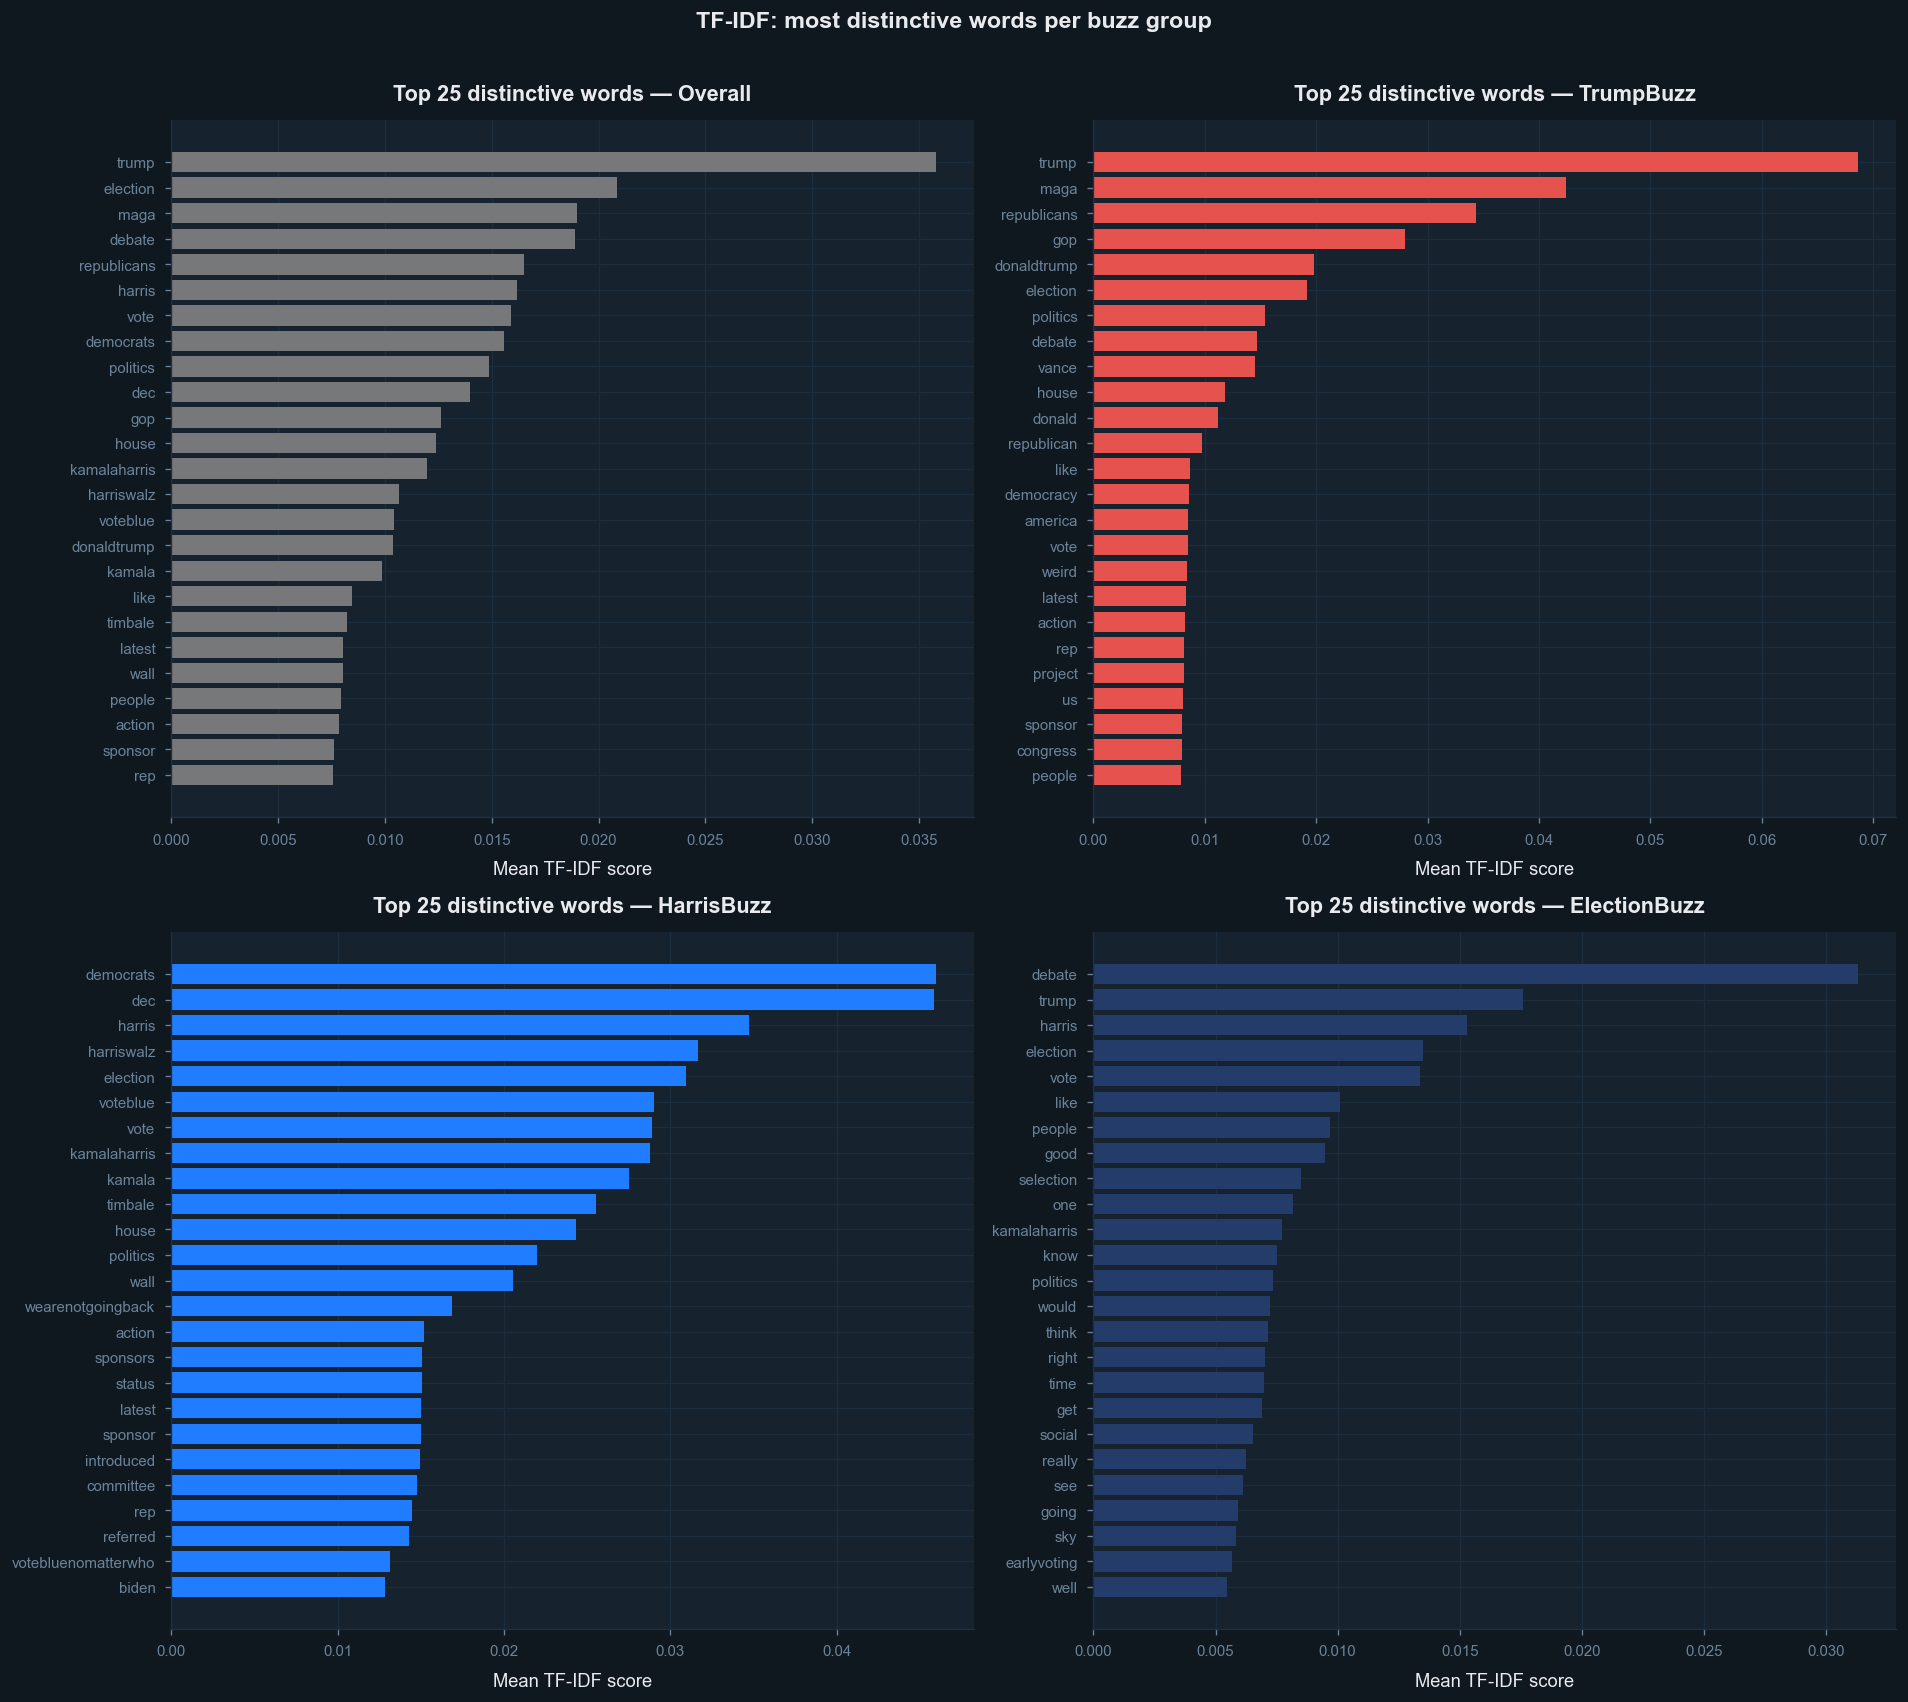

In [55]:
GROUPS     = ['Overall', 'TrumpBuzz', 'HarrisBuzz', 'ElectionBuzz']
colors_bar = {
    'Overall':      NEUTRAL,
    'TrumpBuzz':    REPUBLICAN,
    'HarrisBuzz':   DEMOCRAT,
    'ElectionBuzz': ACCENT,
}

n_rows = tfidf_matrix_2.shape[0]  # derive from the new matrix

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.patch.set_facecolor(BG_DARK)

for ax, group in zip(axes.flat, GROUPS):
    mask = (np.ones(n_rows, dtype=bool) if group == 'Overall'
            else (df_new['candidate'] == group).values)

    mean_scores = tfidf_matrix_2[mask].mean(axis=0).A1
    top_idx     = mean_scores.argsort()[::-1][:25]

    ax.barh(feature_names_2[top_idx][::-1], mean_scores[top_idx][::-1], color=colors_bar[group])
    ax.set_facecolor(BG_PANEL)
    ax.set_title(f'Top 25 distinctive words — {group}',
                 color=TEXT_PRIMARY, fontweight='bold')
    ax.set_xlabel('Mean TF-IDF score', color=TEXT_PRIMARY)
    ax.tick_params(colors=TEXT_MUTED)

plt.suptitle('TF-IDF: most distinctive words per buzz group',
             fontsize=14, color=TEXT_PRIMARY, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. SVD / Latent Semantic Analysis

### Singular Value Decomposition (SVD) / Latent Semantic Analysis

The TF-IDF matrix has tens of thousands of dimensions — far too many for most downstream models. Truncated SVD (the engine behind Latent Semantic Analysis) compresses this into a small number of *latent concepts* that capture the main axes of variation in the corpus. Each concept is a weighted combination of terms that tend to co-occur, revealing thematic structure that individual word counts miss. The reduced representation is denser, faster to compute with, and less sensitive to surface-level lexical variation.

In [56]:
# Start with maximum possible components
# For TruncatedSVD: n_components < min(n_samples, n_features)
n_docs = tfidf_matrix_2.shape[0]
n_terms = tfidf_matrix_2.shape[1]
max_components = min(n_docs, n_terms) - 1

print(f"Original matrix shape: {tfidf_matrix_2.shape}")
print(f"Maximum components: {max_components}")

# Apply TruncatedSVD with all possible components
svd_full = TruncatedSVD(n_components=min(100, max_components), random_state=42)
documents_concepts_full = svd_full.fit_transform(tfidf_matrix_2)

print(f"\nReduced matrix shape: {documents_concepts_full.shape}")
print(f"Dimensionality reduction: {n_terms} → {documents_concepts_full.shape[1]}")

Original matrix shape: (22859, 24875)
Maximum components: 22858

Reduced matrix shape: (22859, 100)
Dimensionality reduction: 24875 → 100


In [57]:
# 1. U matrix (document-by-concept): returned by transform()
print("1. Document-by-Concept Matrix (U):")
print(f"   Shape: {documents_concepts_full.shape}")
print(f"   This is what we use as features for machine learning!")
print(f"\n   First 5 documents, first 5 concepts:")
print(documents_concepts_full[:5, :5])

# 2. Sigma (Σ): singular values (strength of each concept)
print("\n2. Singular Values (Σ - diagonal of sigma matrix):")
print(f"   Shape: {svd_full.singular_values_.shape}")
print(f"   First 10 values: {svd_full.singular_values_[:10]}")

# 3. V^T matrix (concept-by-term): components_
print("\n3. Concept-by-Term Matrix (V^T):")
print(f"   Shape: {svd_full.components_.shape}")
print(f"   Shows how terms contribute to each concept")

1. Document-by-Concept Matrix (U):
   Shape: (22859, 100)
   This is what we use as features for machine learning!

   First 5 documents, first 5 concepts:
[[ 0.00894637  0.04335713  0.04991126 -0.01465526 -0.03429113]
 [ 0.04160973  0.13400575  0.08536689 -0.03565086 -0.03764202]
 [ 0.02388934  0.05256342  0.02401581 -0.05356087  0.06768167]
 [ 0.01897395  0.09248105  0.07734274  0.01059017 -0.03129919]
 [ 0.04142137  0.08336492  0.10518652  0.07547171 -0.1288691 ]]

2. Singular Values (Σ - diagonal of sigma matrix):
   Shape: (100,)
   First 10 values: [19.81917142 17.13245291 13.39732014 11.5122607  10.54294653 10.00638245
  9.6594407   9.41672682  9.23916825  8.50266683]

3. Concept-by-Term Matrix (V^T):
   Shape: (100, 24875)
   Shows how terms contribute to each concept


#### Interpreting Latent Concepts

Each SVD component represents a latent semantic concept — an abstract topic defined by the words that load most strongly on it. The first concept typically captures the broadest shared theme in the corpus (general election discourse), while later concepts separate more specific sub-topics. The sign of a term's loading indicates whether it is positively or negatively associated with that concept axis. Examining the top-weighted terms per concept lets us attach a human-interpretable label to each dimension before using them as features in downstream models.

In [58]:
def display_top_terms_per_concept(svd_model, feature_names, n_top=10, n_concepts=5):
    """Display top terms for each latent concept."""
    for i in range(min(n_concepts, svd_model.n_components)):
        # Get component weights for all terms
        component = svd_model.components_[i]
        
        # Get indices of top terms (by absolute value)
        top_indices = np.argsort(np.abs(component))[::-1][:n_top]
        top_terms = [feature_names[idx] for idx in top_indices]
        top_weights = [component[idx] for idx in top_indices]
        
        print(f"\nConcept {i+1} (σ = {svd_full.singular_values_[i]:.3f}):")
        for term, weight in zip(top_terms, top_weights):
            print(f"  {term:20s} {weight:>8.4f}")

display_top_terms_per_concept(svd_full, feature_names, n_top=10, n_concepts=2)


Concept 1 (σ = 19.819):
  grant                  0.3951
  restrict               0.2561
  restriction            0.2533
  ackleyia               0.2530
  rightwingattacks       0.2525
  inpersonvoting         0.2512
  hidden                 0.2484
  clams                  0.2449
  paving                 0.2342
  peterfiller            0.2341

Concept 2 (σ = 17.132):
  doctorwho              0.3665
  socialmediamarketing   0.3378
  surveyusa              0.2742
  netanyahu              0.2377
  gates                  0.2081
  illegals               0.1971
  survivor               0.1927
  gayvalimont            0.1675
  jubilant               0.1664
  cyclonic               0.1619


#### Explained Variance

The singular values quantify how much of the total variance in the DTM each concept captures. A scree plot shows where the explained variance per component levels off — the "elbow" — which guides how many components to retain. We also track cumulative explained variance to find the smallest number of concepts that still preserve a meaningful share (e.g., 80%) of the original information. Retaining too few components discards signal; retaining too many reintroduces noise and increases compute cost.

In [59]:
# Calculate variance explained by each component
# Variance is proportional to squared singular values
variance = svd_full.singular_values_ ** 2

# Calculate percentage of variance explained
total_variance = np.sum(variance)
explained_variance_ratio = variance / total_variance

# Cumulative variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Variance Explained:")
print(f"{'Component':<12} {'Variance':<12} {'% Explained':<15} {'Cumulative %':<15}")
print("-" * 60)
for i in range(min(10, len(explained_variance_ratio))):
    print(f"{i+1:<12} {variance[i]:<12.4f} {explained_variance_ratio[i]*100:<15.2f} {cumulative_variance[i]*100:<15.2f}")

print(f"\nFirst 3 components explain {cumulative_variance[2]*100:.1f}% of variance")
print(f"First 5 components explain {cumulative_variance[4]*100:.1f}% of variance")

Variance Explained:
Component    Variance     % Explained     Cumulative %   
------------------------------------------------------------
1            392.7996     9.30            9.30           
2            293.5209     6.95            16.25          
3            179.4882     4.25            20.50          
4            132.5321     3.14            23.63          
5            111.1537     2.63            26.27          
6            100.1277     2.37            28.64          
7            93.3048      2.21            30.85          
8            88.6747      2.10            32.94          
9            85.3622      2.02            34.97          
10           72.2953      1.71            36.68          

First 3 components explain 20.5% of variance
First 5 components explain 26.3% of variance


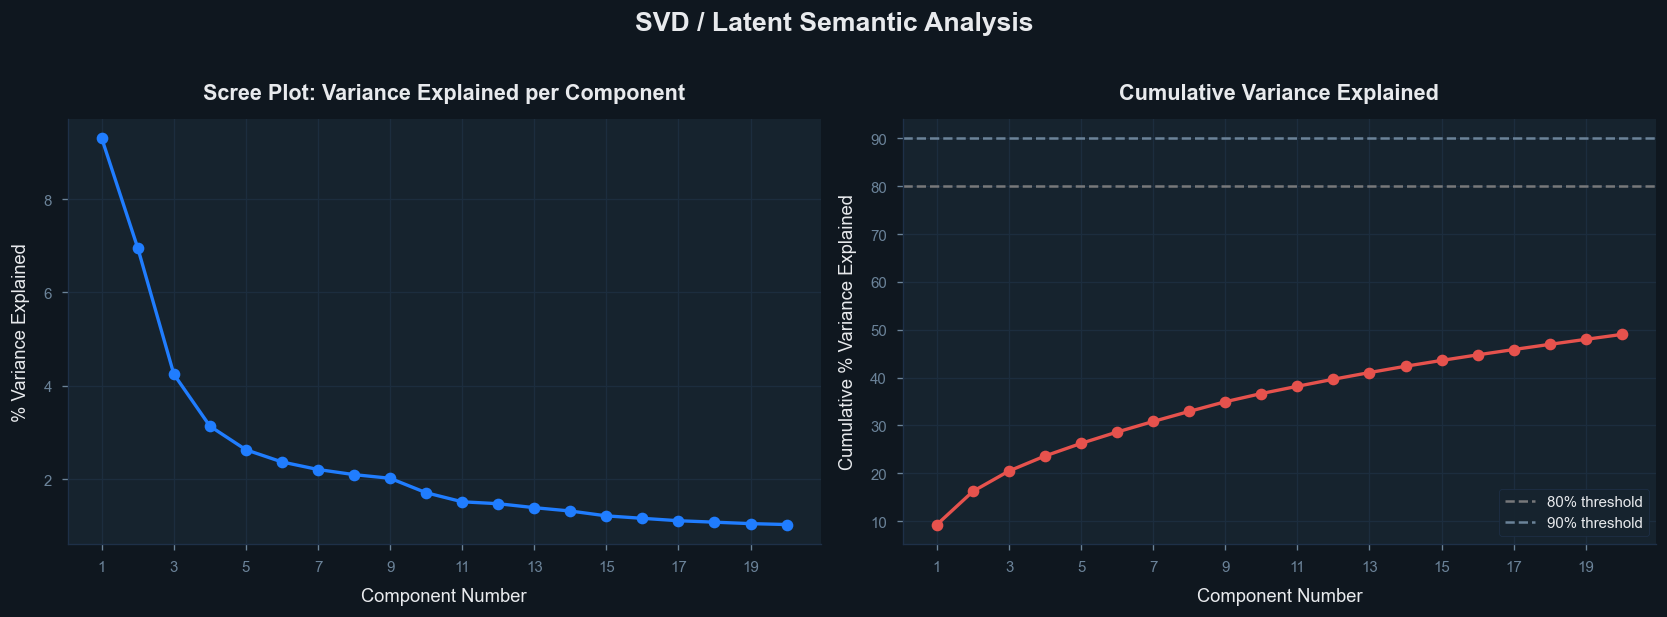

80% variance explained with 61 components
90% variance explained with 79 components
95% variance explained with 89 components


In [60]:
n_components_to_plot = min(20, len(explained_variance_ratio))
x = range(1, n_components_to_plot + 1)

fig, axes = styled_fig(1, 2, figsize=(14, 5), title="SVD / Latent Semantic Analysis")

# Plot 1: Variance per component 
axes[0].plot(x, explained_variance_ratio[:n_components_to_plot] * 100,
             color=DEMOCRAT, linewidth=2, marker='o', markersize=6)
axes[0].set_xlabel('Component Number')
axes[0].set_ylabel('% Variance Explained')
axes[0].set_title('Scree Plot: Variance Explained per Component')
axes[0].set_xticks(range(1, n_components_to_plot + 1, 2))

# Plot 2: Cumulative variance 
axes[1].plot(x, cumulative_variance[:n_components_to_plot] * 100,
             color=REPUBLICAN, linewidth=2, marker='o', markersize=6)
axes[1].axhline(80, color=NEUTRAL,   linestyle='--', linewidth=1.5, label='80% threshold')
axes[1].axhline(90, color=TEXT_MUTED, linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].set_xlabel('Component Number')
axes[1].set_ylabel('Cumulative % Variance Explained')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xticks(range(1, n_components_to_plot + 1, 2))
axes[1].legend()

plt.tight_layout()
plt.show()

# Thresholds 
for threshold in [0.80, 0.90, 0.95]:
    n_comp = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{threshold*100:.0f}% variance explained with {n_comp} components")

In [61]:
n_components_optimal = np.argmax(cumulative_variance >= 0.80) + 1

print(f"Using {n_components_optimal} components (explains {cumulative_variance[n_components_optimal-1]*100:.1f}% of variance)")

lsa = TruncatedSVD(n_components=n_components_optimal, random_state=42)
documents_lsa = lsa.fit_transform(tfidf_matrix_2)  # ← was tfidf_matrix

print(f"\nOriginal dimensionality: {tfidf_matrix_2.shape[1]} terms")
print(f"Reduced dimensionality: {documents_lsa.shape[1]} concepts")
print(f"Dimensionality reduction: {(1 - documents_lsa.shape[1]/tfidf_matrix_2.shape[1])*100:.1f}%")

Using 61 components (explains 80.1% of variance)

Original dimensionality: 24875 terms
Reduced dimensionality: 61 concepts
Dimensionality reduction: 99.8%


In [62]:
documents_lsa.shape

(22859, 61)

In [63]:
df_new.shape

(22859, 16)

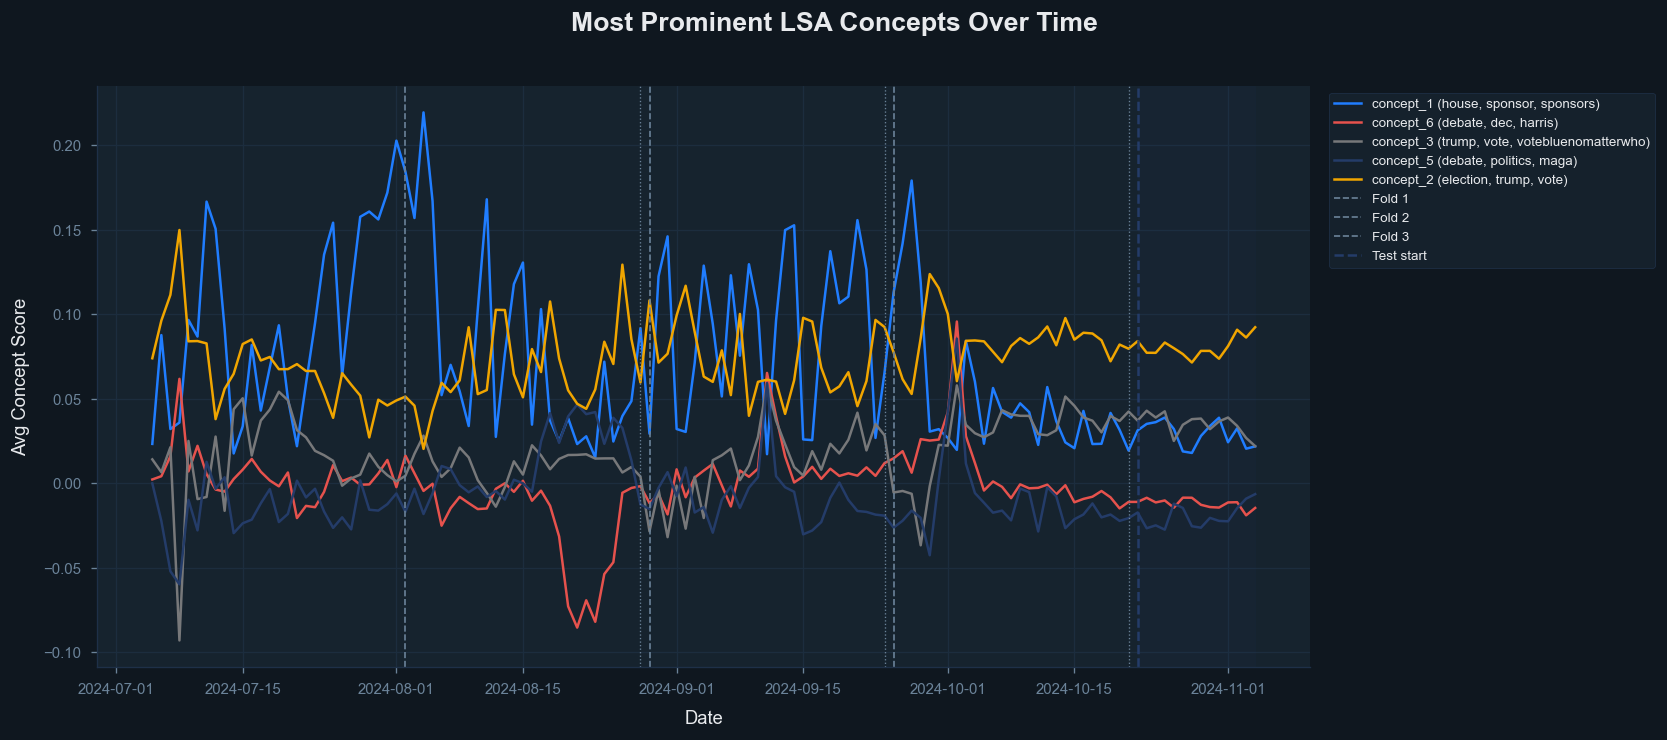

In [65]:
# ── Add date back ─────────────────────────────────────────────────────────────
lsa_cols = [f'concept_{i+1}' for i in range(n_components_optimal)]
lsa_df   = pd.DataFrame(documents_lsa, columns=lsa_cols, index=df_new.index)
lsa_df['date'] = df_new['date'].values

# ── Daily average per concept ─────────────────────────────────────────────────
daily_concepts = lsa_df.groupby('date')[lsa_cols].mean()
top_concepts   = daily_concepts.var().nlargest(5).index.tolist()

# ── Get fold boundaries ───────────────────────────────────────────────────────
folds            = get_cv_folds(daily_concepts.reset_index(), n_splits=3, gap=1, test_days=14)
tv_idx, test_idx = get_test_split(daily_concepts.reset_index(), test_days=14)

dates            = daily_concepts.index
test_start       = dates[tv_idx[-1] + 1]
fold_val_starts, fold_val_ends = [], []
for train_idx, val_idx in folds:
    fold_val_starts.append(dates[val_idx[0]])
    fold_val_ends.append(dates[val_idx[-1]])

# ── Single plot ───────────────────────────────────────────────────────────────
concept_colors = [DEMOCRAT, REPUBLICAN, NEUTRAL, ACCENT, "#f0a500"]

fig, ax = styled_fig(figsize=(14, 6),
                     title='Most Prominent LSA Concepts Over Time')

for concept, color in zip(top_concepts, concept_colors):
    idx       = int(concept.split('_')[1]) - 1
    component = lsa.components_[idx]
    top_terms = [vectorizer.get_feature_names_out()[i]
                 for i in np.argsort(np.abs(component))[::-1][:3]]
    label = f"{concept} ({', '.join(top_terms)})"
    ax.plot(daily_concepts.index, daily_concepts[concept],
            color=color, linewidth=1.5, label=label)

# ── Fold boundaries ───────────────────────────────────────────────────────────
for i, (val_start, val_end) in enumerate(zip(fold_val_starts, fold_val_ends), 1):
    ax.axvline(val_start, color=TEXT_MUTED, linestyle='--', linewidth=1,
               label=f'Fold {i}' if i == 1 else f'Fold {i}')
    ax.axvline(val_end,   color=TEXT_MUTED, linestyle=':',  linewidth=0.8)

# ── Test boundary ─────────────────────────────────────────────────────────────
ax.axvline(test_start, color=ACCENT, linestyle='--', linewidth=1.5, label='Test start')
ax.axvspan(test_start, dates[-1],    alpha=0.08,     color=ACCENT)

ax.set_xlabel('Date')
ax.set_ylabel('Avg Concept Score')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

In [66]:
for concept in top_concepts:
    idx       = int(concept.split('_')[1]) - 1
    component = lsa.components_[idx]
    top_terms = vectorizer.get_feature_names_out()[np.argsort(component)[::-1][:10]]
    print(f"{concept}: {', '.join(top_terms)}")

concept_1: house, sponsor, sponsors, action, status, latest, introduced, committee, referred, rep
concept_6: debate, vance, fightfascism, saveamerica, gop, defenddemocracy, vote, republicans, voteblue, bluewave
concept_3: trump, maga, debate, gop, republicans, politics, vance, donald, donaldtrump, harris
concept_5: debate, politics, dec, voteblue, election, wall, donate, vance, democrats, secure
concept_2: election, trump, vote, politics, harris, kamalaharris, voteblue, harriswalz, maga, democrats


## 5. Key Term Frequency Over Time

### Key Term Frequency Over Time

Tracking how often specific politically salient terms appear week-by-week — normalised by total post volume per buzz group — reveals how the conversation shifted in response to campaign events. Normalisation is important: raw counts would be dominated by weeks with higher overall activity. Comparing the share across TrumpBuzz, HarrisBuzz, and ElectionBuzz shows whether certain topics resonate differently within each candidate's audience.

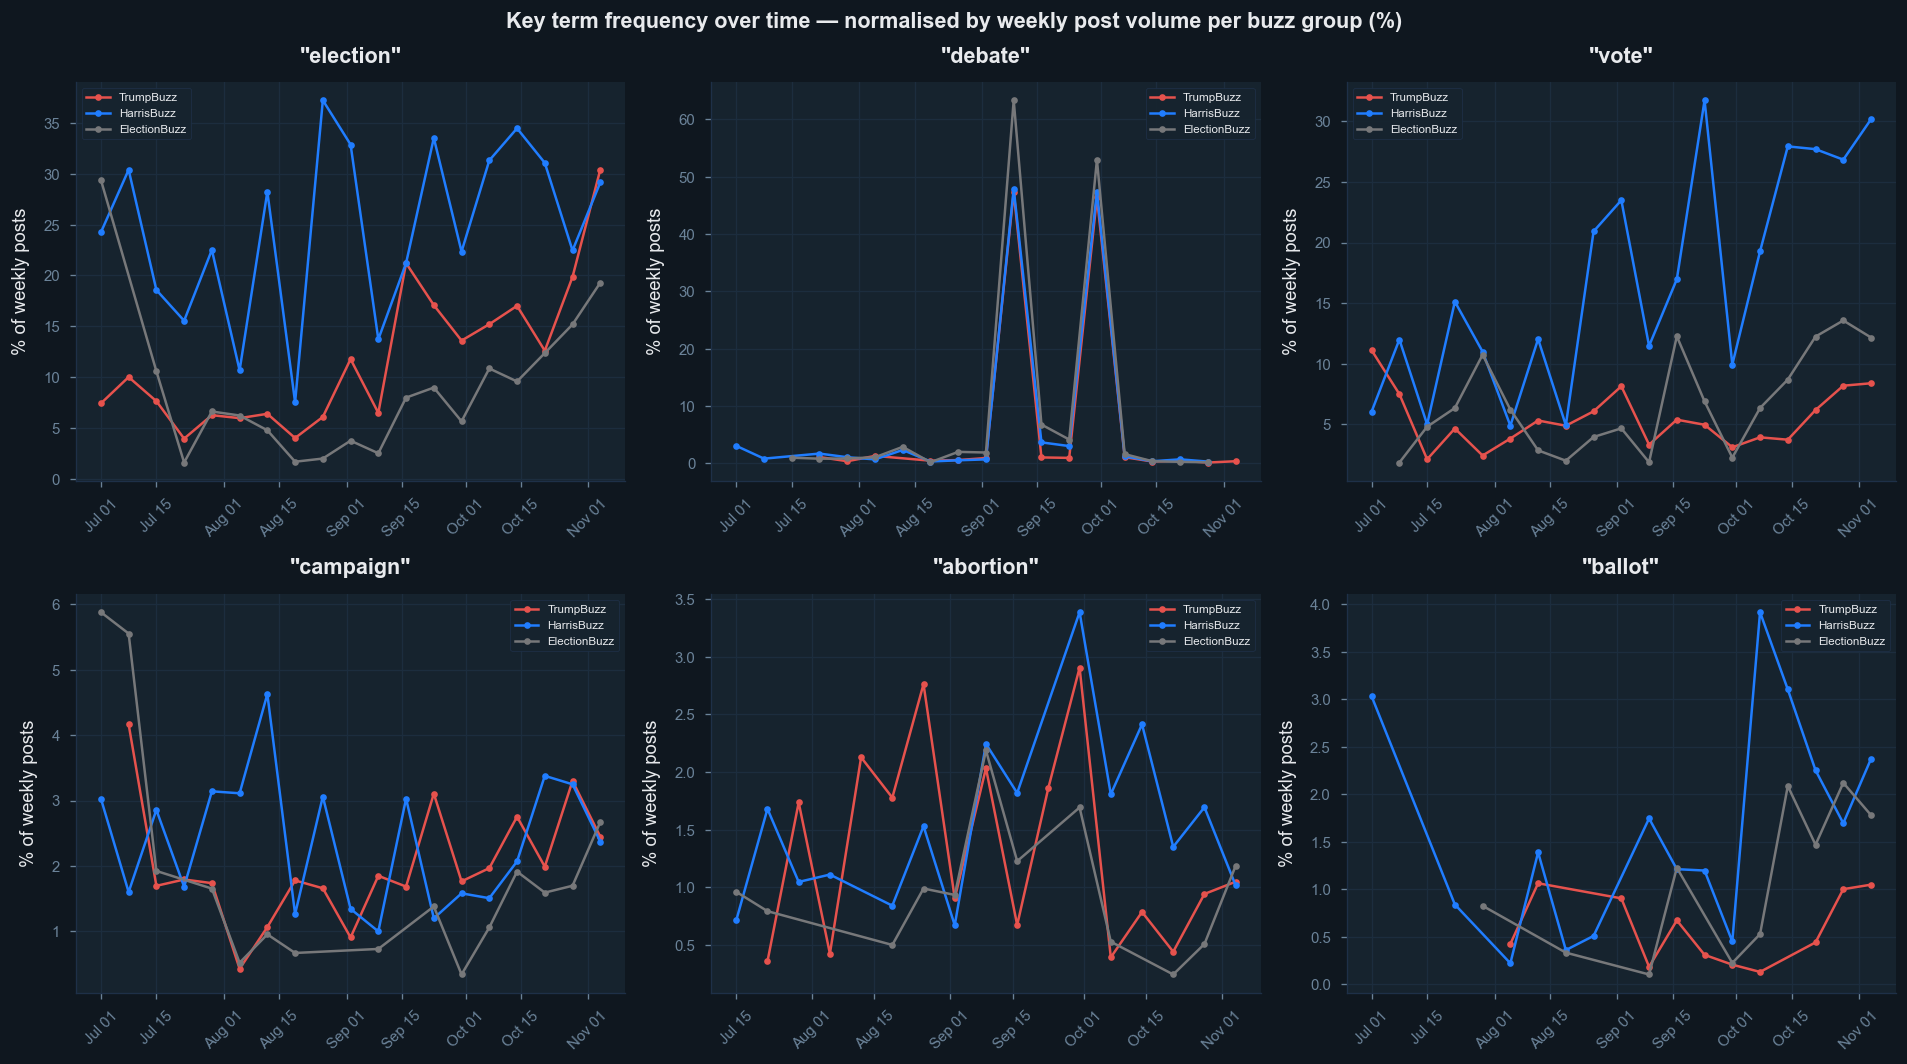

In [68]:
TRACK_TERMS = [
    'debate', 'poll', 'abortion', 'immigration', 'economy',
    'campaign', 'vote', 'election', 'swing', 'battleground',
    'conviction', 'assassination', 'concede', 'ballot', 'tariff'
]

# ── Weekly totals per buzz group ──────────────────────────────────────────────
df_new['week'] = pd.to_datetime(df_new['date']).dt.to_period('W').dt.start_time

weekly_totals = (
    df_new.groupby(['week', 'candidate'])
    .size()
    .reset_index(name='total')
)

# ── Count term occurrences per week per buzz group ────────────────────────────
results = []
for term in TRACK_TERMS:
    mask   = df_new['text_norm'].str.contains(r'\b' + term + r'\b', regex=True, na=False)
    weekly = df_new[mask].groupby(['week', 'candidate']).size().reset_index(name='count')
    weekly = weekly.merge(weekly_totals, on=['week', 'candidate'])
    weekly['share'] = weekly['count'] / weekly['total']
    weekly['term']  = term
    results.append(weekly)

term_df   = pd.concat(results, ignore_index=True)
top_terms = term_df.groupby('term')['count'].sum().nlargest(6).index.tolist()

# ── Plot ──────────────────────────────────────────────────────────────────────
colors_line = {
    'TrumpBuzz':    REPUBLICAN,
    'HarrisBuzz':   DEMOCRAT,
    'ElectionBuzz': NEUTRAL,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(BG_DARK)

for ax, term in zip(axes.flat, top_terms):
    ax.set_facecolor(BG_PANEL)
    subset = term_df[term_df['term'] == term]

    for group, color in colors_line.items():
        data = subset[subset['candidate'] == group]
        if not data.empty:
            ax.plot(data['week'], data['share'] * 100,
                    color=color, marker='o', ms=3,
                    linewidth=1.5, label=group)

    ax.set_title(f'"{term}"', color=TEXT_PRIMARY, fontweight='bold')
    ax.set_ylabel('% of weekly posts', color=TEXT_PRIMARY)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=45, colors=TEXT_MUTED)
    ax.tick_params(axis='y', colors=TEXT_MUTED)
    ax.legend(fontsize=7)

plt.suptitle('Key term frequency over time — normalised by weekly post volume per buzz group (%)',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Word Clouds

Word clouds visualise the TF-IDF-weighted vocabulary for each buzz group, giving an immediate intuition of which terms are most distinctive per group. Because the weights are derived from TF-IDF rather than raw frequency, common words shared across all posts are suppressed — what remains are the terms that genuinely differentiate one group's discourse from another.

In [69]:
WC_COLORS = {**BUZZ_COLORS, "Overall": TEXT_PRIMARY}

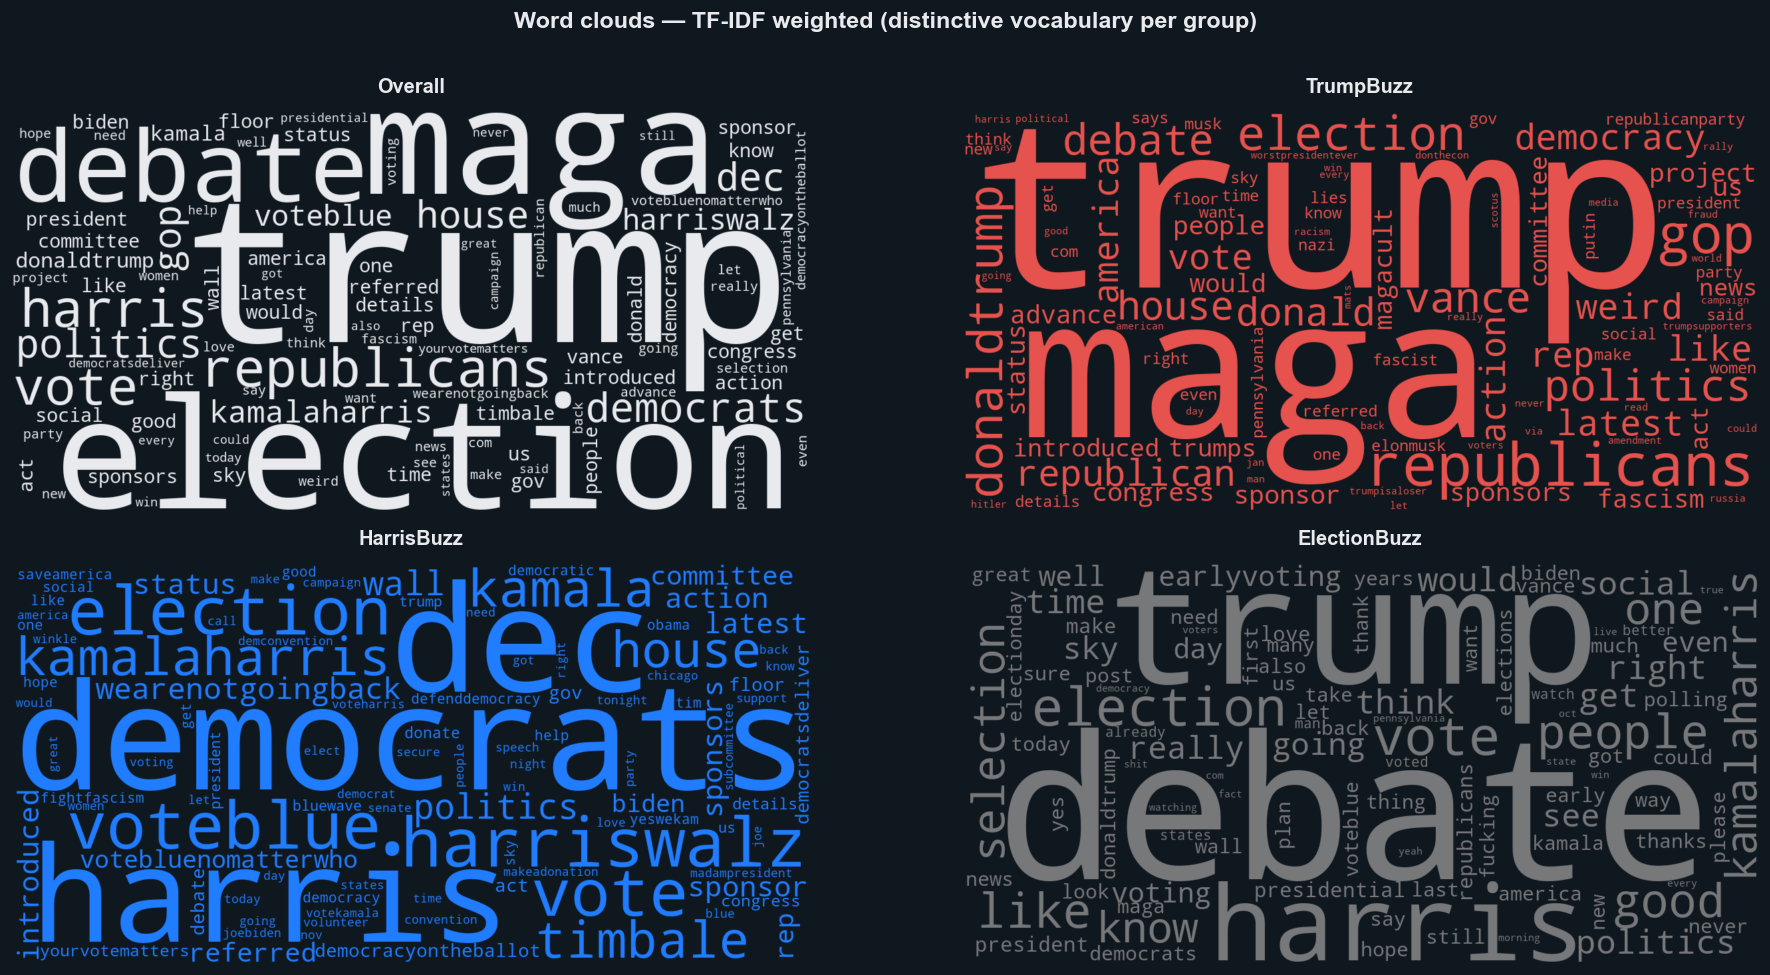

In [70]:
ALL_GROUPS = {
    'Overall':      df_new,
    'TrumpBuzz':    df_new[df_new['candidate'] == 'TrumpBuzz'],
    'HarrisBuzz':   df_new[df_new['candidate'] == 'HarrisBuzz'],
    'ElectionBuzz': df_new[df_new['candidate'] == 'ElectionBuzz'],
}

def make_wc_tfidf(scores_dict, color):
    return WordCloud(
        width=1200, height=600,
        background_color=BG_DARK,
        max_words=100,
        collocations=False,
        color_func=lambda *args, **kwargs: color,
        relative_scaling=0.4,
        min_word_length=3,
    ).generate_from_frequencies(scores_dict)

def plot_wc_grid(wc_dict, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(16, 8), facecolor=BG_DARK)
    for ax, (label, wc) in zip(axes.flat, wc_dict.items()):
        ax.set_facecolor(BG_DARK)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(label, fontsize=12, fontweight='bold', color=TEXT_PRIMARY)
    fig.suptitle(suptitle, fontsize=14, color=TEXT_PRIMARY, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

wc_tfidf = {}
for label, sub in ALL_GROUPS.items():
    mask        = df_new.index.isin(sub.index)
    mean_scores = tfidf_matrix_2[mask].mean(axis=0).A1
    scores_dict = {feature_names_2[i]: mean_scores[i] for i in mean_scores.argsort()[::-1][:200]}
    wc_tfidf[label] = make_wc_tfidf(scores_dict, WC_COLORS[label])

plot_wc_grid(wc_tfidf, 'Word clouds — TF-IDF weighted (distinctive vocabulary per group)')